# ERICA end-to-end test at K=4 — VDX 3-gene and VDX full

Companion notebook for `e2e_test.py`. Same canonical pipeline at fixed K=4 on:

1. **VDX 3-gene subset** (344 samples × 3 genes) — fast, runs in seconds.
2. **VDX full** (344 samples × 22 283 genes) — needs `data/vdx_full.npz`; see [`README_vdx_full.md`](README_vdx_full.md) for the one-shot conversion.

Plot ordering: MATLAB-recap figures first (`plot_assignment_scatter`, `plot_assignment_heatmap`), then enriched library figures (`plot_pcsp`, `plot_icah`, CLAM heatmap, cluster sizes, stability strips).

**Prerequisite:** `pip install erica` (>= 0.2.4) — installs all plotting deps.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from erica import (
    ERICA,
    set_publication_style,
    plot_assignment_scatter,
    plot_assignment_heatmap,
    plot_pcsp,
    plot_icah,
    plot_clam_heatmap_mpl,
    plot_cluster_sizes_mpl,
    plot_stability_strips,
)

set_publication_style()
%matplotlib inline

K = 4
METHODS = ['kmeans', 'agglomerative_ward']

## 1. VDX 3-gene

Tiny 3-gene subset distributed in the repo. Use it to sanity-check the
pipeline before running the full microarray.

In [2]:
X3 = pd.read_csv(os.path.join('..', 'examples', 'data', 'VDX_3_SV.csv'),
                 header=None).to_numpy()
print('VDX 3-gene shape:', X3.shape)

er3 = ERICA(
    data=X3,
    k_range=[K],
    n_iterations=200,
    method=METHODS,
    transpose=False,
    random_state=123,
    verbose=False,
)
results3 = er3.run()
for m in METHODS:
    metrics = results3['metrics'][K][m]
    print(f"  {m:22s}  CRI={metrics['CRI']:.3f}  WCRI={metrics['WCRI']:.3f}  TWCRI={metrics['TWCRI']:.3f}")

VDX 3-gene shape: (344, 3)

=== Cluster Index Summary ===
CRI: 0.867081

CRI_per_cluster: [0.9795431308772158, 0.7361487218272216, 0.9051256032983441, 0.8475076382392426]
WCRI: 0.217065

WCRI_per_cluster: [0.28759841924011276, 0.1733373443837353, 0.12892777488842694, 0.2783964044216117]
TWCRI: 0.868260

cluster_sizes: [101, 81, 49, 113]
k: 4
has_empty_clusters: False


=== Cluster Index Summary ===
CRI: 0.784288

CRI_per_cluster: [0.8935882663300004, 0.7629001429004343, 0.8747828540920526, 0.6058805983665505]
WCRI: 0.200473

WCRI_per_cluster: [0.2623616712189827, 0.4014096682121471, 0.09409001628315682, 0.044032020230127214]
TWCRI: 0.801893

cluster_sizes: [101, 181, 37, 25]
k: 4
has_empty_clusters: False

  kmeans                  CRI=0.867  WCRI=0.217  TWCRI=0.868
  agglomerative_ward      CRI=0.784  WCRI=0.200  TWCRI=0.802


### MATLAB-recap figures — VDX 3-gene

Two plots that recapitulate the original `clam_matrix_sort_18a.m`
MATLAB script: percent-scale 1×K assignment scatter and the K×K
cross-assignment heatmap. K-Means only here for brevity.

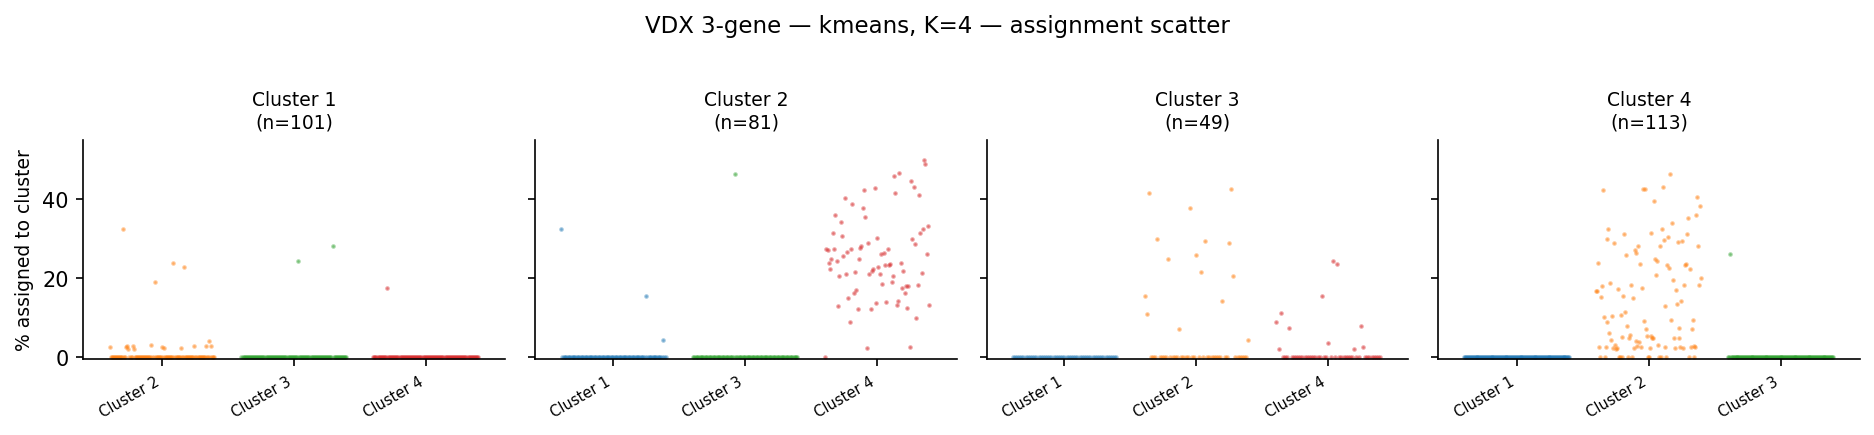

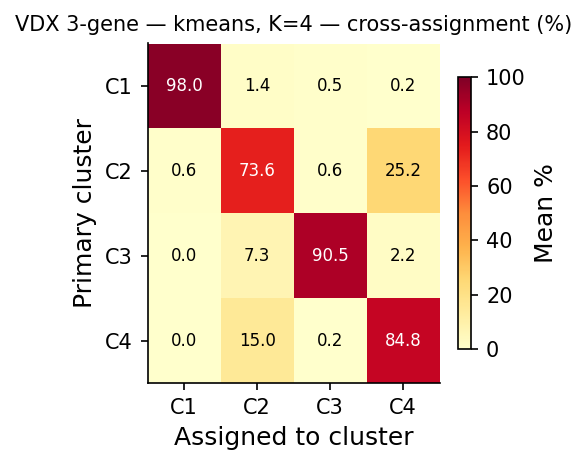

In [3]:
method = 'kmeans'
clam3 = results3['clam_matrices'][(K, method)]

fig = plot_assignment_scatter(clam3, method=method, k=K,
                              title=f'VDX 3-gene — {method}, K={K} — assignment scatter')
plt.show()

fig, _ = plot_assignment_heatmap(clam3, k=K,
                                 title=f'VDX 3-gene — {method}, K={K} — cross-assignment (%)')
plt.show()

### Enriched library figures — VDX 3-gene

PCSP (image-style with U-notation annotations), ICAH (proportion heatmap),
CLAM heatmap, cluster sizes, stability strips.

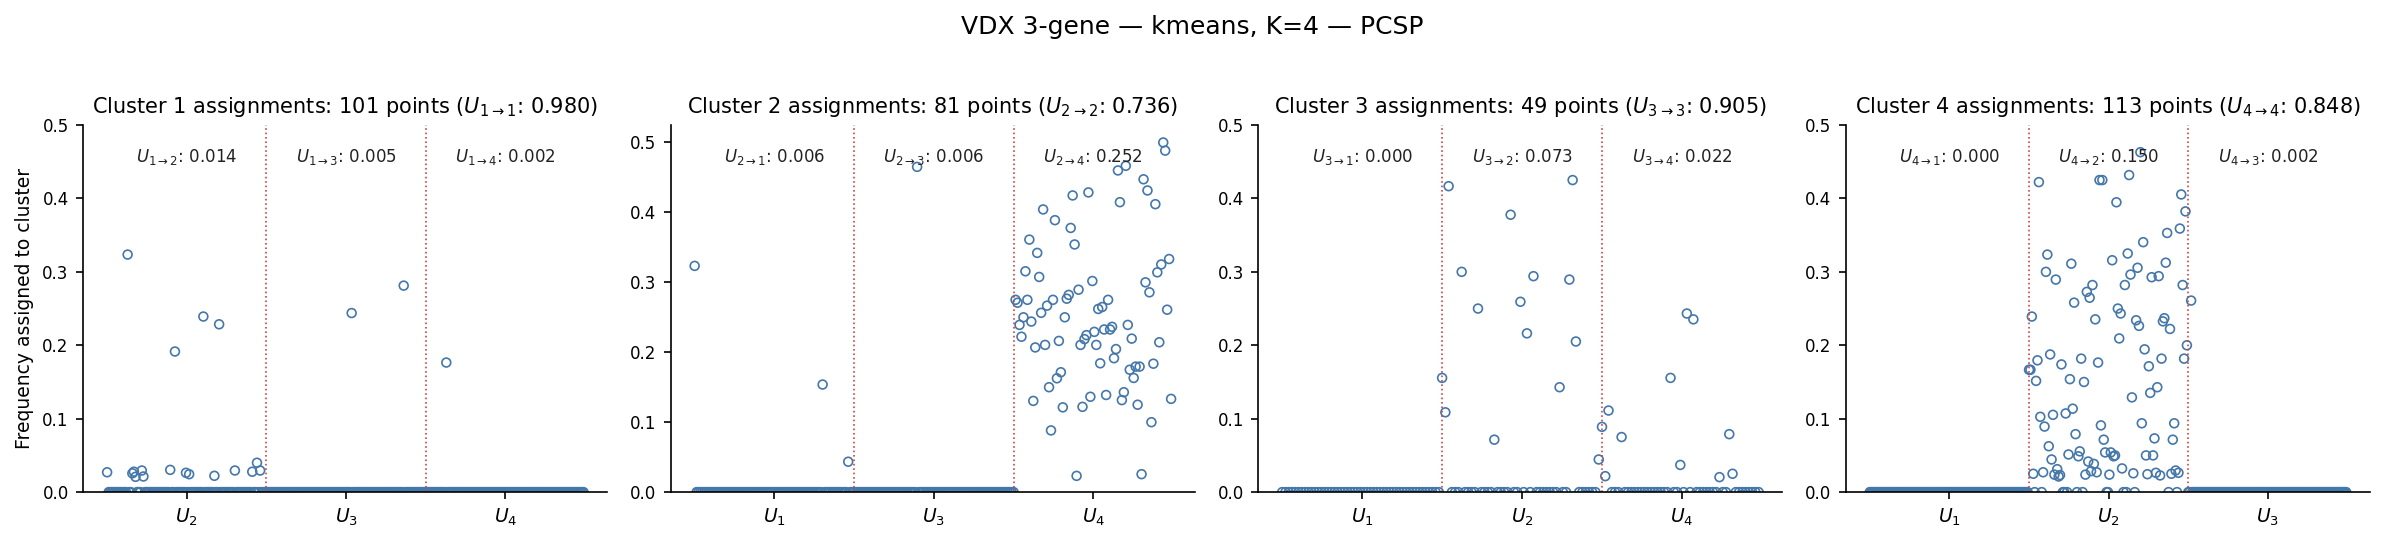

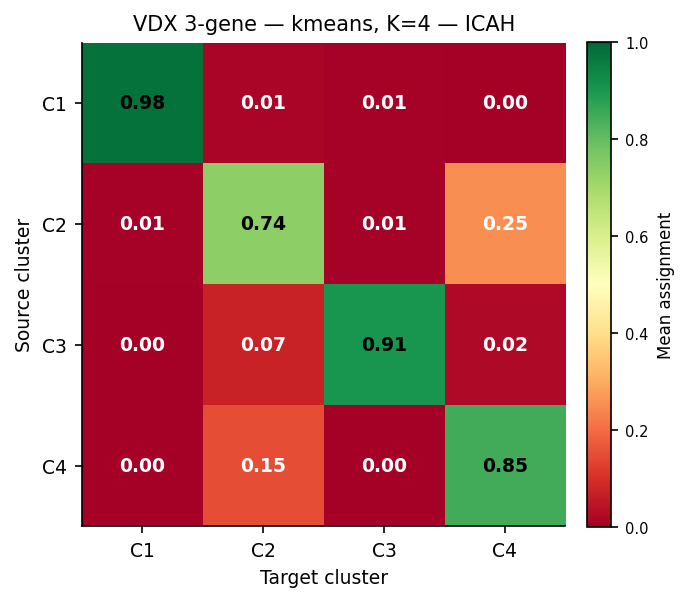

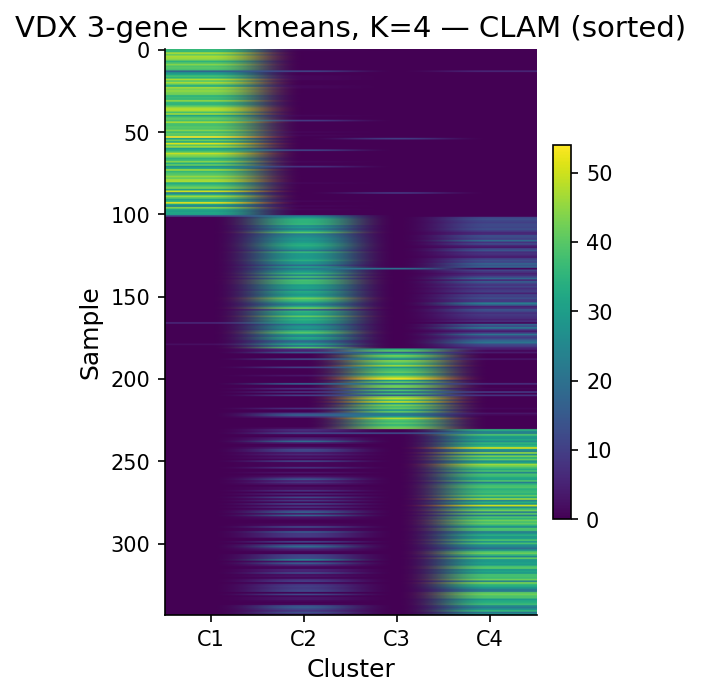

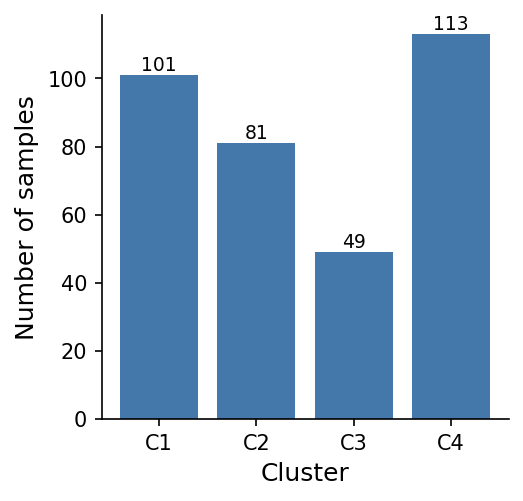

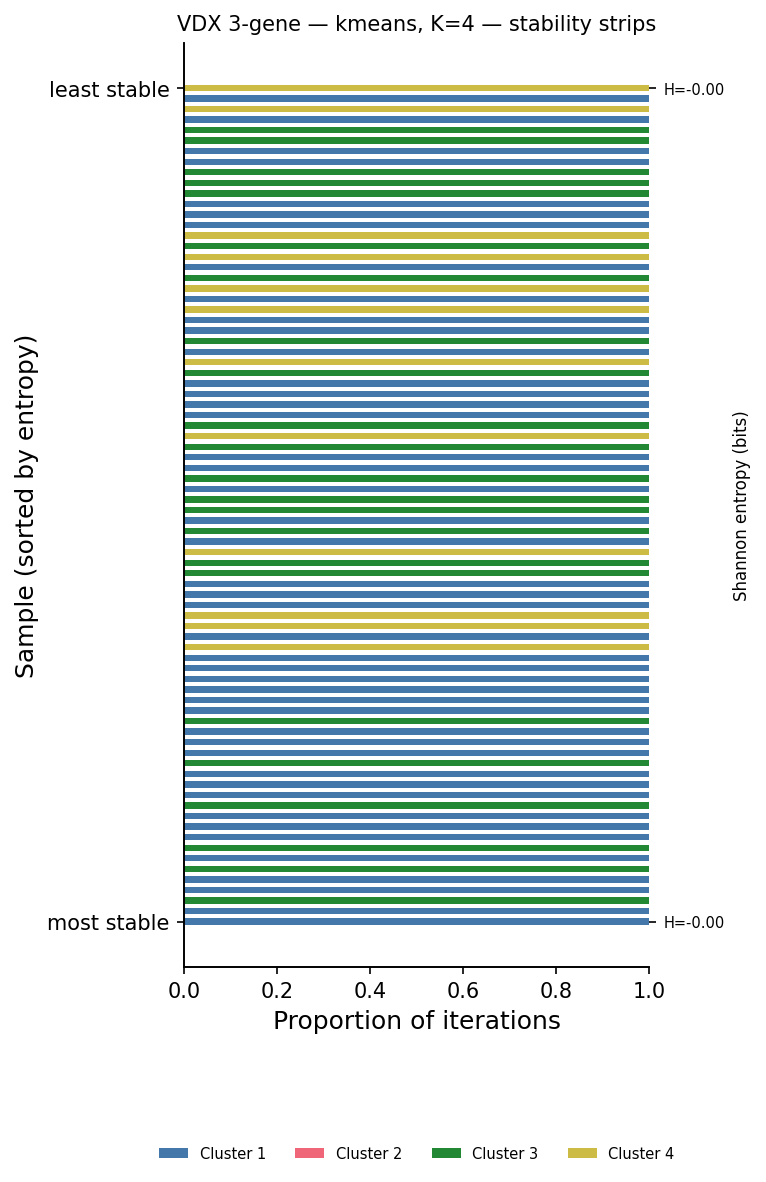

In [4]:
fig = plot_pcsp(clam3, k=K, title=f'VDX 3-gene — {method}, K={K} — PCSP')
plt.show()

fig, _ = plot_icah(clam3, k=K, title=f'VDX 3-gene — {method}, K={K} — ICAH')
plt.show()

fig, _ = plot_clam_heatmap_mpl(clam3, sort=True,
                                title=f'VDX 3-gene — {method}, K={K} — CLAM (sorted)')
plt.show()

fig, _ = plot_cluster_sizes_mpl(clam3)
plt.show()

fig, _ = plot_stability_strips(clam3, max_samples=80,
                                title=f'VDX 3-gene — {method}, K={K} — stability strips')
plt.show()

## 2. VDX full (344 × 22 283)

Loads from the safe `vdx_full.npz` cache. If you don't have it yet,
see [`README_vdx_full.md`](README_vdx_full.md) for the one-shot
download + convert command.

In [5]:
VDX_FULL_NPZ = os.path.join('data', 'vdx_full.npz')

if not os.path.exists(VDX_FULL_NPZ):
    raise FileNotFoundError(
        f'Missing {VDX_FULL_NPZ}. See README_vdx_full.md for setup.'
    )

Xf = np.load(VDX_FULL_NPZ)['X_all']
print('VDX full shape:', Xf.shape)

erf = ERICA(
    data=Xf,
    k_range=[K],
    n_iterations=200,
    method=METHODS,
    transpose=False,
    random_state=123,
    verbose=False,
)
resultsf = erf.run()
for m in METHODS:
    metrics = resultsf['metrics'][K][m]
    print(f"  {m:22s}  CRI={metrics['CRI']:.3f}  WCRI={metrics['WCRI']:.3f}  TWCRI={metrics['TWCRI']:.3f}")

VDX full shape: (344, 22283)

=== Cluster Index Summary ===
CRI: 0.446013

CRI_per_cluster: [0.49368683691744825, 0.4511495409560078, 0.45404577668141666, 0.385171385912648]
WCRI: 0.114519

WCRI_per_cluster: [0.10189466692191519, 0.2413125451625158, 0.10031243903426647, 0.014555895397861698]
TWCRI: 0.458076

cluster_sizes: [71, 184, 76, 13]
k: 4
has_empty_clusters: False


=== Cluster Index Summary ===
CRI: 0.685654

CRI_per_cluster: [0.6941117306445018, 0.7751680650420247, 0.6241024100272237, 0.6492324575134821]
WCRI: 0.169851

WCRI_per_cluster: [0.22397209913238283, 0.15548429211598752, 0.23766690614408809, 0.06228102063356078]
TWCRI: 0.679404

cluster_sizes: [111, 69, 131, 33]
k: 4
has_empty_clusters: False

  kmeans                  CRI=0.446  WCRI=0.115  TWCRI=0.458
  agglomerative_ward      CRI=0.686  WCRI=0.170  TWCRI=0.679


### MATLAB-recap figures — VDX full

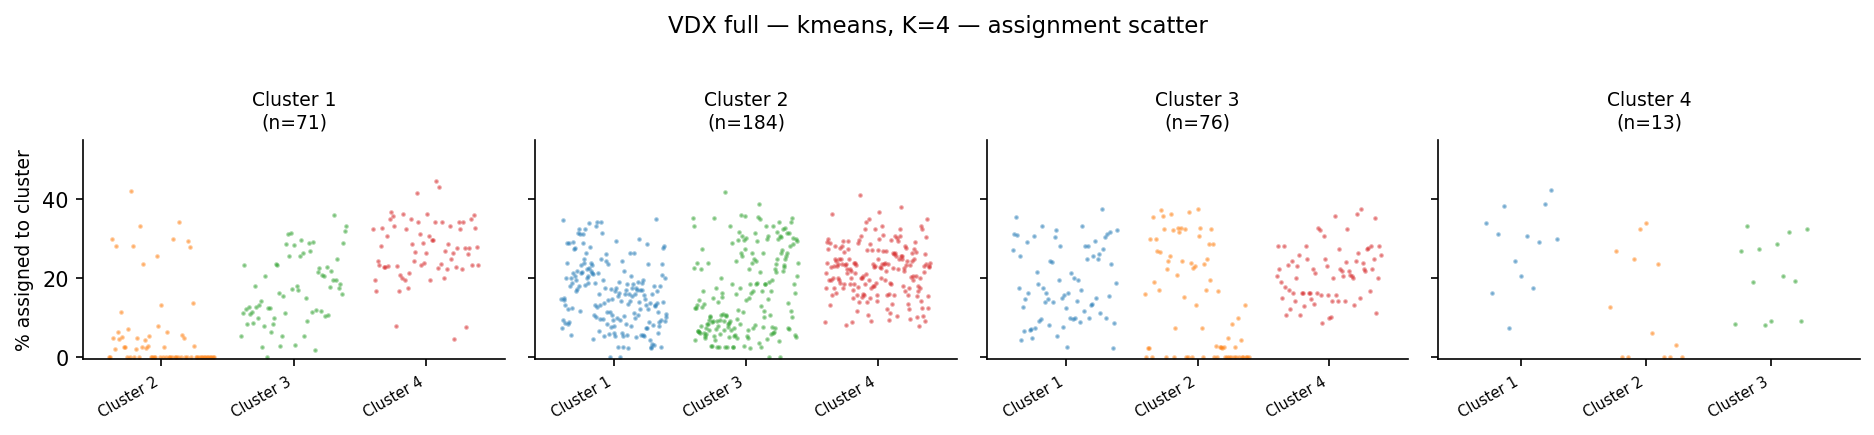

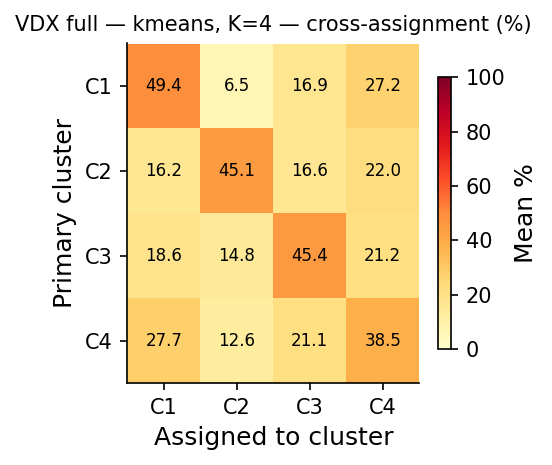

In [6]:
clamf = resultsf['clam_matrices'][(K, method)]

fig = plot_assignment_scatter(clamf, method=method, k=K,
                              title=f'VDX full — {method}, K={K} — assignment scatter')
plt.show()

fig, _ = plot_assignment_heatmap(clamf, k=K,
                                 title=f'VDX full — {method}, K={K} — cross-assignment (%)')
plt.show()

### Enriched library figures — VDX full

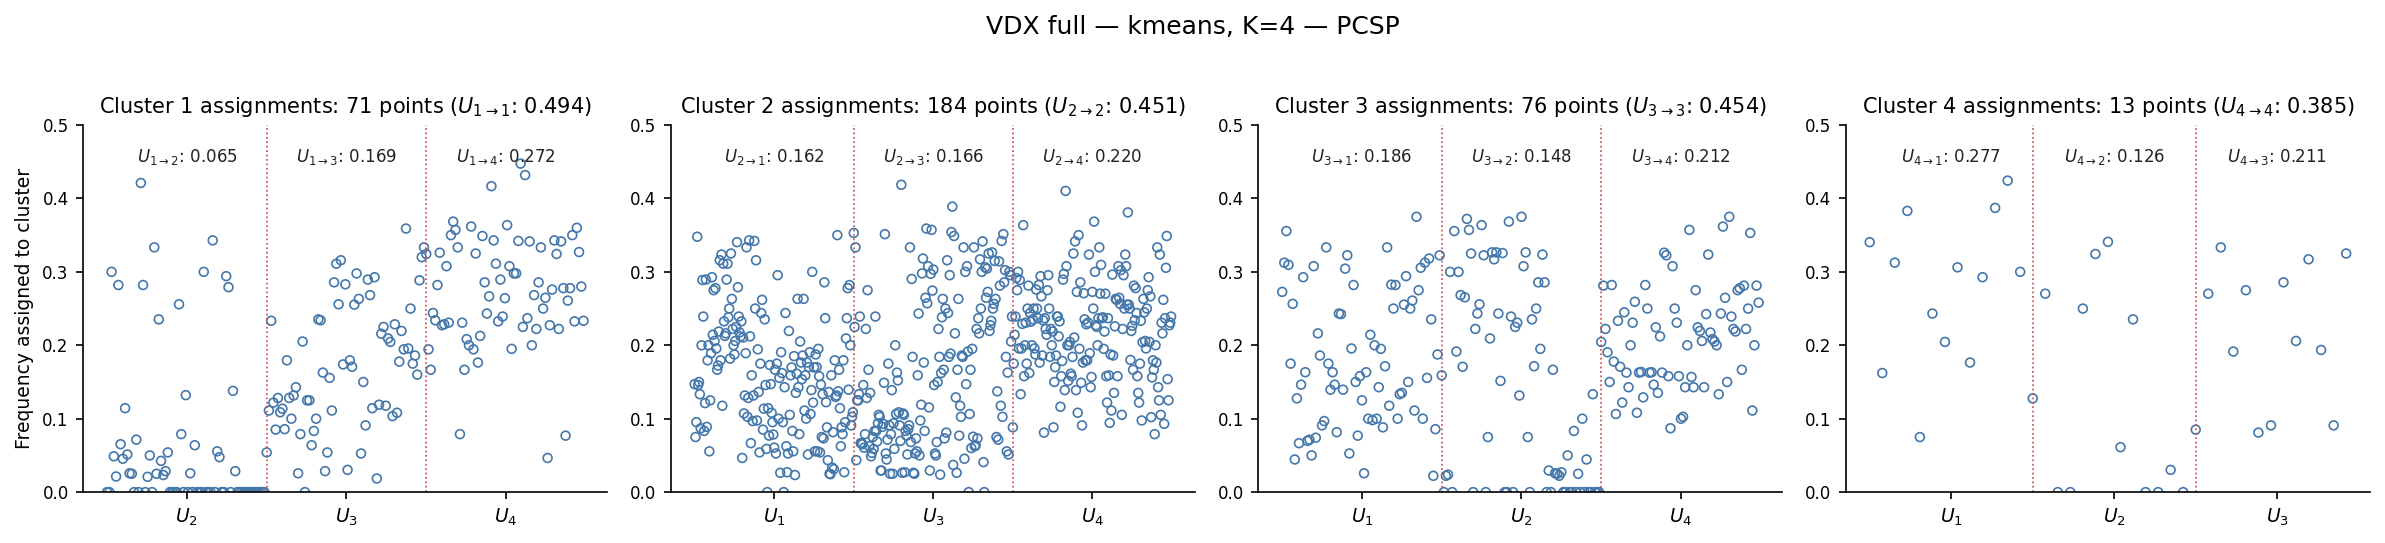

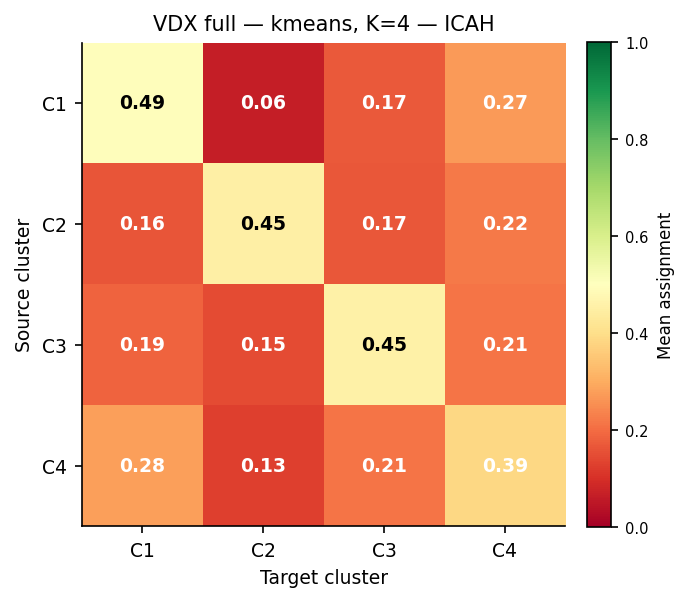

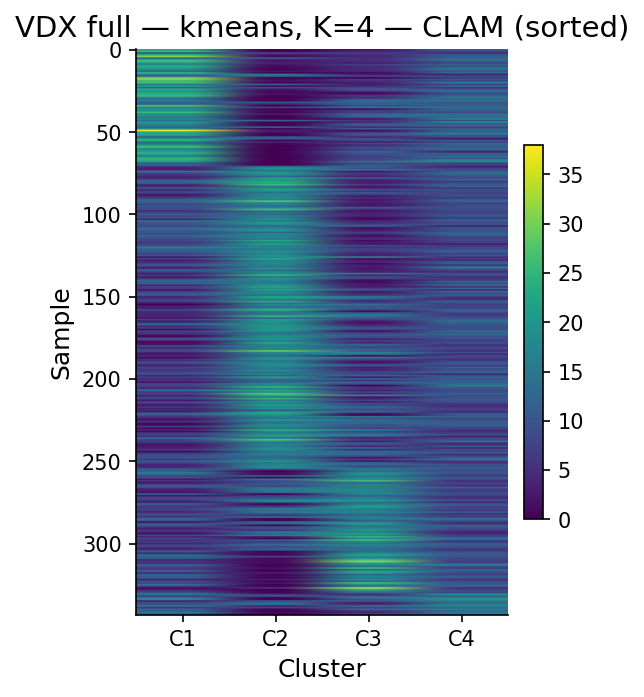

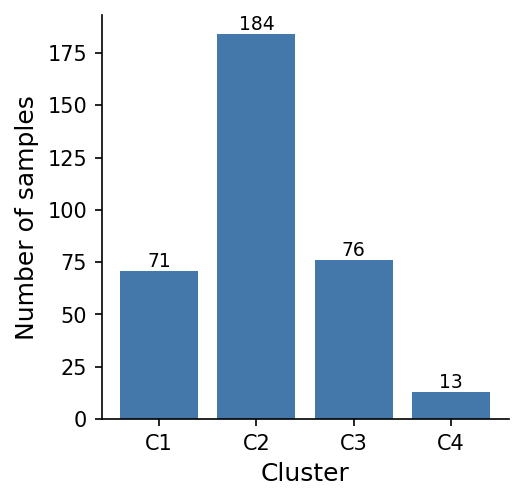

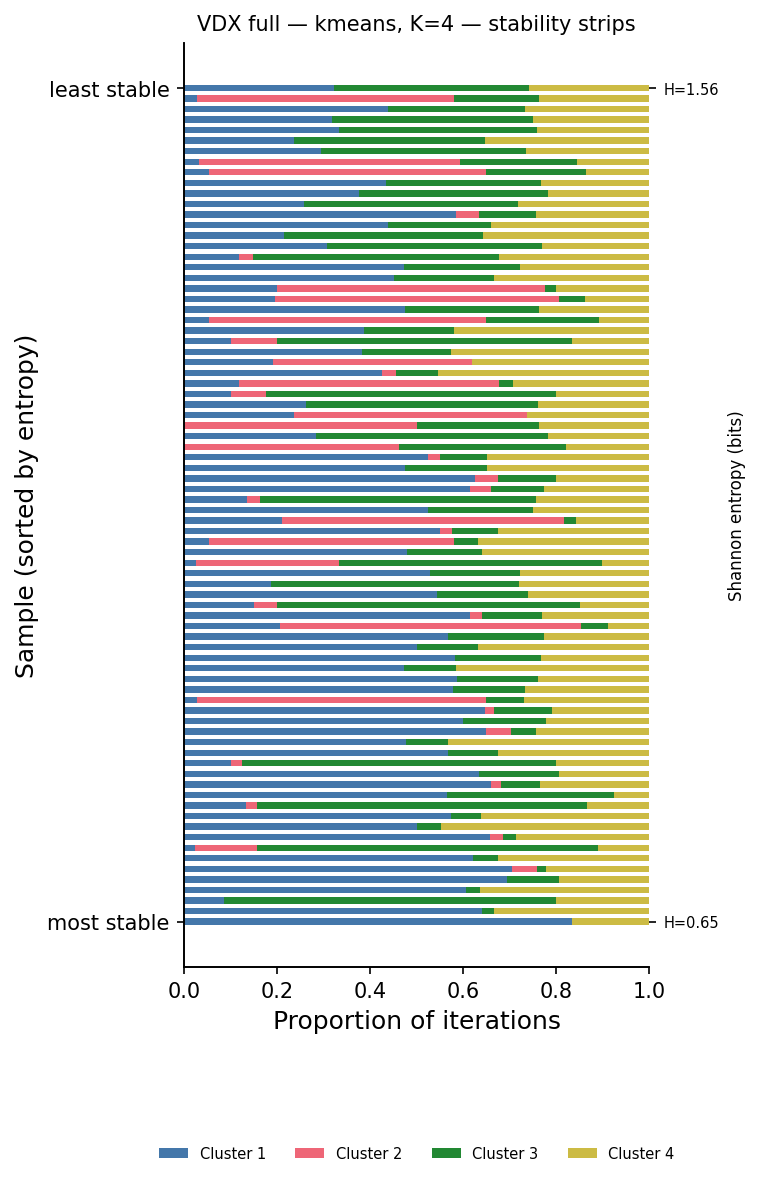

In [7]:
fig = plot_pcsp(clamf, k=K, title=f'VDX full — {method}, K={K} — PCSP')
plt.show()

fig, _ = plot_icah(clamf, k=K, title=f'VDX full — {method}, K={K} — ICAH')
plt.show()

fig, _ = plot_clam_heatmap_mpl(clamf, sort=True,
                                title=f'VDX full — {method}, K={K} — CLAM (sorted)')
plt.show()

fig, _ = plot_cluster_sizes_mpl(clamf)
plt.show()

fig, _ = plot_stability_strips(clamf, max_samples=80,
                                title=f'VDX full — {method}, K={K} — stability strips')
plt.show()

## Recap

Same library, same plots, two scales of input — 3 genes vs 22 283 genes.
Use `er.run(...)` once, then any of the plotters takes the resulting
CLAM matrix as a single argument.

Saved CLAMs from the matching script (`e2e_test.py`) live under
`figures/e2e_test/<dataset>/clams/clam_<method>_K4.npz` and can be
loaded with `np.load(...)['clam']` to reproduce any of these plots
without re-running ERICA.